# ⚡ EV Range Intelligence — Energy Consumption Prediction
**Vehicle:** BMW i3 (60 Ah) — Real driving data from Munich, Germany

**Dataset:** 69 real trips (32 summer + 37 winter), 1M+ sensor readings at 10Hz

**Target:** Classify trips as High or Low energy consumption (kWh/km)

**Models:** HistGradientBoosting vs Random Forest

**Methodology:** CRISP-DM (Cross-Industry Standard Process for Data Mining)

---
## Phase 1 — Business Understanding (CRISP-DM)
Electric vehicles lose up to 30-40% of their range in cold weather due to cabin heating and reduced battery efficiency. Accurately predicting energy consumption based on driving conditions, climate, and terrain helps drivers plan trips and avoid range anxiety.

**Objective:** Build a classification model that predicts whether a trip will have high or low energy consumption, and estimate the remaining driving range.

**Success Criteria:** ROC-AUC > 0.85, Accuracy > 80%

---
## Phase 2 — Data Understanding

### 2.1 — Data Loading
70 CSV files (TripA01-A32 = summer, TripB01-B38 = winter), each containing high-frequency sensor data from a BMW i3. We combine them into a single DataFrame, keeping the 24 columns common to all trips.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import warnings
warnings.filterwarnings('ignore')

path = "DATA/"

all_trips = []
for f in sorted(glob.glob(path + "Trip*.csv")):
    name = os.path.basename(f).replace('.csv', '')
    df = pd.read_csv(f, sep=';', encoding='latin1')
    df['Trip'] = name
    df['Season'] = 'Summer' if 'A' in name else 'Winter'
    all_trips.append(df)

# Drop TripB38 (missing Velocity column)
all_trips = [t for t in all_trips if t['Trip'].iloc[0] != 'TripB38']

# Keep 24 columns common to all 69 trips
use_cols = [
    'Time [s]', 'Velocity [km/h]', 'Elevation [m]', 'Throttle [%]',
    'Motor Torque [Nm]', 'Longitudinal Acceleration [m/s^2]',
    'Regenerative Braking Signal ', 'Battery Voltage [V]',
    'Battery Current [A]', 'Battery Temperature [°C]',
    'max. Battery Temperature [°C]', 'SoC [%]', 'displayed SoC [%]',
    'min. SoC [%]', 'max. SoC [%)',
    'Heating Power CAN [kW]', 'Requested Heating Power [W]',
    'AirCon Power [kW]', 'Heater Signal',
    'Ambient Temperature [°C]',
    'Heat Exchanger Temperature [°C]', 'Cabin Temperature Sensor [°C]',
    'Trip', 'Season'
]

df = pd.concat([t[use_cols] for t in all_trips], ignore_index=True)

print(f"Shape: {df.shape}")
print(f"Trips: {df['Trip'].nunique()}")
print(f"Summer: {(df['Season']=='Summer').sum():,} rows")
print(f"Winter: {(df['Season']=='Winter').sum():,} rows")
print(f"Nulls: {df.isnull().sum().sum():,}")

Shape: (1078364, 24)
Trips: 69
Summer: 467,701 rows
Winter: 610,663 rows
Nulls: 123,174


### 2.2 — Data Exploration

In [4]:
print("=== NULLS ===")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\n=== DTYPES ===")
print(df.dtypes)

print("\n=== KEY STATS ===")
stats = {
    'Velocity': df['Velocity [km/h]'],
    'SoC': df['SoC [%]'],
    'Battery Temp': df['Battery Temperature [°C]'],
    'Ambient Temp': df['Ambient Temperature [°C]'],
    'Battery Current': df['Battery Current [A]'],
    'Elevation': df['Elevation [m]'],
    'Heating Power': df['Heating Power CAN [kW]'],
    'AirCon Power': df['AirCon Power [kW]'],
}
for name, col in stats.items():
    print(f"  {name:20s} min={col.min():.1f}  max={col.max():.1f}  mean={col.mean():.2f}")

=== NULLS ===
SoC [%]              30793
displayed SoC [%]    30794
min. SoC [%]         30793
max. SoC [%)         30794
dtype: int64

=== DTYPES ===
Time [s]                             float64
Velocity [km/h]                      float64
Elevation [m]                        float64
Throttle [%]                         float64
Motor Torque [Nm]                    float64
Longitudinal Acceleration [m/s^2]    float64
Regenerative Braking Signal          float64
Battery Voltage [V]                  float64
Battery Current [A]                  float64
Battery Temperature [°C]             float64
max. Battery Temperature [°C]        float64
SoC [%]                              float64
displayed SoC [%]                    float64
min. SoC [%]                         float64
max. SoC [%)                         float64
Heating Power CAN [kW]               float64
Requested Heating Power [W]          float64
AirCon Power [kW]                    float64
Heater Signal                          

In [ ]:
df.describe()

---
## Phase 3 — Data Preparation

### 3.1 — Data Cleaning
SoC nulls (2.9%) are sensor micro-gaps — the signal drops for a few readings then returns. We use forward-fill within each trip to interpolate, then backward-fill for any remaining nulls at trip start.

In [5]:
# Forward-fill SoC nulls within each trip (sensor gaps)
soc_cols = ['SoC [%]', 'displayed SoC [%]', 'min. SoC [%]', 'max. SoC [%)']
df[soc_cols] = df.groupby('Trip')[soc_cols].ffill()
df[soc_cols] = df.groupby('Trip')[soc_cols].bfill()

# Drop any remaining nulls
before = len(df)
df = df.dropna()
after = len(df)
print(f"Dropped: {before - after} rows ({(before-after)/before*100:.2f}%)")

# Sanity checks
df = df[df['Velocity [km/h]'] >= 0]
df = df[df['SoC [%]'] >= 0]
df = df[df['SoC [%]'] <= 100]

print(f"Final shape: {df.shape}")
print(f"Nulls: {df.isnull().sum().sum()}")
print(f"Trips: {df['Trip'].nunique()}")

Dropped: 0 rows (0.00%)
Final shape: (1078364, 24)
Nulls: 0
Trips: 69


### 3.2 — Feature Engineering
Raw sensor data at 10Hz needs to be transformed into meaningful features. We create 15 new features across 5 categories: power, speed, acceleration, climate, and terrain.

In [6]:
# 1. Power consumption (instantaneous) = Voltage x Current
df['Power [kW]'] = (df['Battery Voltage [V]'] * df['Battery Current [A]']) / 1000

# 2. Speed categories
df['Is_Stationary'] = (df['Velocity [km/h]'] == 0).astype(int)
df['Is_Highway'] = (df['Velocity [km/h]'] > 80).astype(int)
df['Is_City'] = ((df['Velocity [km/h]'] > 0) & (df['Velocity [km/h]'] <= 50)).astype(int)

# 3. Acceleration categories
df['Is_Braking'] = (df['Longitudinal Acceleration [m/s^2]'] < -0.5).astype(int)
df['Is_Accelerating'] = (df['Longitudinal Acceleration [m/s^2]'] > 0.5).astype(int)
df['Is_Regen'] = (df['Regenerative Braking Signal '] > 0).astype(int)

# 4. Climate load
df['Heating_Active'] = (df['Heating Power CAN [kW]'] > 0).astype(int)
df['AC_Active'] = (df['AirCon Power [kW]'] > 0.5).astype(int)
df['Climate_Power [kW]'] = df['Heating Power CAN [kW]'] + df['AirCon Power [kW]']

# 5. Temperature difference (cabin vs ambient = comfort demand)
df['Temp_Diff [°C]'] = df['Cabin Temperature Sensor [°C]'] - df['Ambient Temperature [°C]']

# 6. Elevation change per step (slope proxy)
df['Elevation_Change [m]'] = df.groupby('Trip')['Elevation [m]'].diff().fillna(0)

# 7. SoC change per step (energy drain rate)
df['SoC_Change'] = df.groupby('Trip')['SoC [%]'].diff().fillna(0)

# 8. Rolling averages (last 30 seconds = 300 rows at 10Hz)
df['Velocity_Rolling_30s'] = df.groupby('Trip')['Velocity [km/h]'].transform(
    lambda x: x.rolling(300, min_periods=1).mean())
df['Power_Rolling_30s'] = df.groupby('Trip')['Power [kW]'].transform(
    lambda x: x.rolling(300, min_periods=1).mean())

print(f"Shape after engineering: {df.shape}")
print(f"\nNew features ({df.shape[1] - 24} added):")
new_cols = df.columns[24:].tolist()
for c in new_cols:
    print(f"  {c}: min={df[c].min():.3f}  max={df[c].max():.3f}")

Shape after engineering: (1078364, 39)

New features (15 added):
  Power [kW]: min=-140.490  max=55.642
  Is_Stationary: min=0.000  max=1.000
  Is_Highway: min=0.000  max=1.000
  Is_City: min=0.000  max=1.000
  Is_Braking: min=0.000  max=1.000
  Is_Accelerating: min=0.000  max=1.000
  Is_Regen: min=0.000  max=1.000
  Heating_Active: min=0.000  max=1.000
  AC_Active: min=0.000  max=1.000
  Climate_Power [kW]: min=0.000  max=39.870
  Temp_Diff [°C]: min=-11.830  max=28.840
  Elevation_Change [m]: min=-1.550  max=27.520
  SoC_Change: min=-34.600  max=0.050
  Velocity_Rolling_30s: min=0.000  max=150.101
  Power_Rolling_30s: min=-72.683  max=48.211


### 3.3 — EDA Visualizations

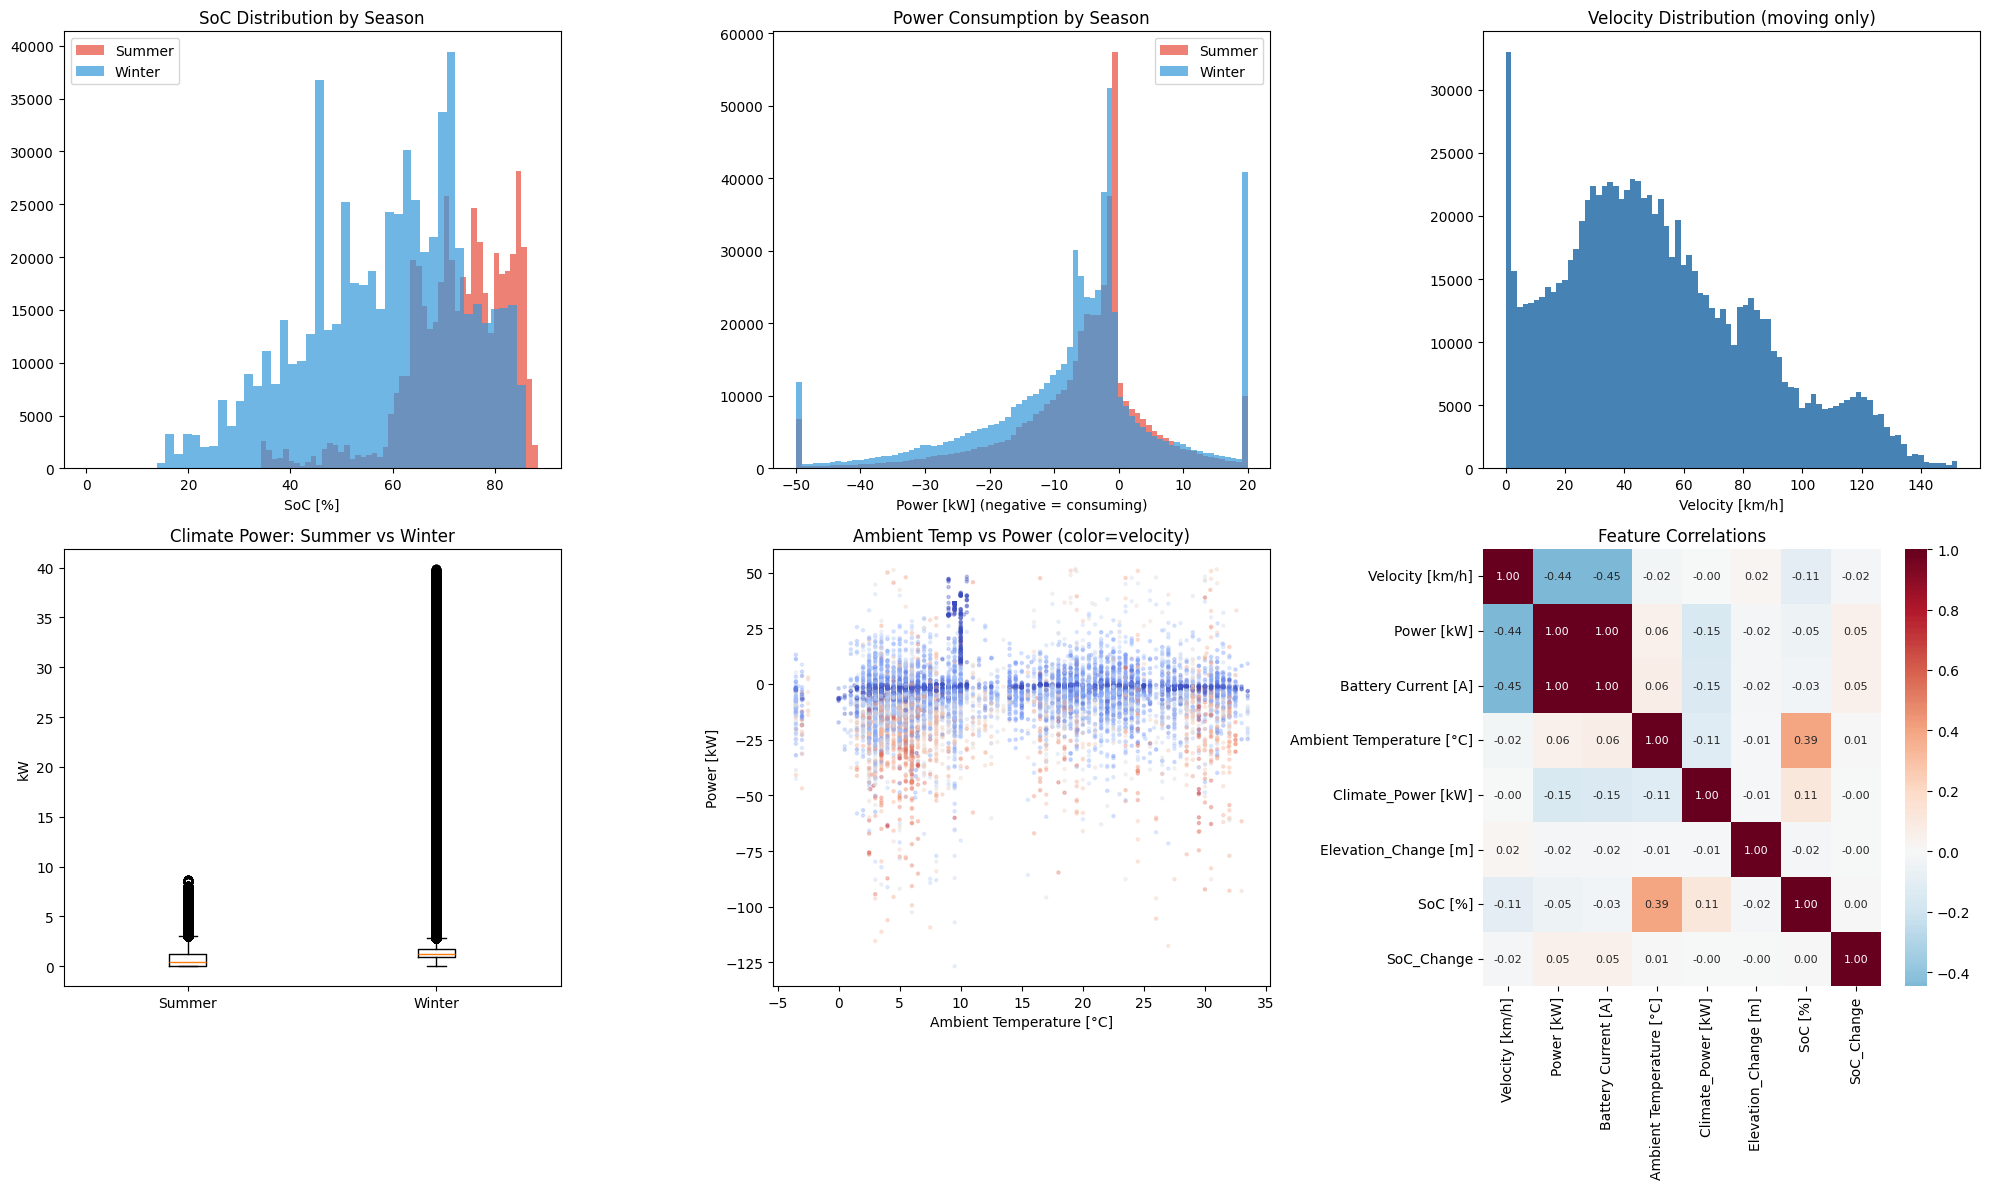

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. SoC distribution by season
axes[0,0].hist(df[df['Season']=='Summer']['SoC [%]'], bins=50, alpha=0.7, label='Summer', color='#e74c3c')
axes[0,0].hist(df[df['Season']=='Winter']['SoC [%]'], bins=50, alpha=0.7, label='Winter', color='#3498db')
axes[0,0].set_title('SoC Distribution by Season')
axes[0,0].set_xlabel('SoC [%]')
axes[0,0].legend()

# 2. Power consumption by season
summer_power = df[df['Season']=='Summer']['Power [kW]'].clip(-50, 20)
winter_power = df[df['Season']=='Winter']['Power [kW]'].clip(-50, 20)
axes[0,1].hist(summer_power, bins=80, alpha=0.7, label='Summer', color='#e74c3c')
axes[0,1].hist(winter_power, bins=80, alpha=0.7, label='Winter', color='#3498db')
axes[0,1].set_title('Power Consumption by Season')
axes[0,1].set_xlabel('Power [kW] (negative = consuming)')
axes[0,1].legend()

# 3. Velocity distribution
axes[0,2].hist(df[df['Velocity [km/h]'] > 0]['Velocity [km/h]'], bins=80, color='steelblue', edgecolor='none')
axes[0,2].set_title('Velocity Distribution (moving only)')
axes[0,2].set_xlabel('Velocity [km/h]')

# 4. Climate power: summer vs winter
climate_summer = df[df['Season']=='Summer']['Climate_Power [kW]']
climate_winter = df[df['Season']=='Winter']['Climate_Power [kW]']
axes[1,0].boxplot([climate_summer, climate_winter], labels=['Summer', 'Winter'])
axes[1,0].set_title('Climate Power: Summer vs Winter')
axes[1,0].set_ylabel('kW')

# 5. Ambient Temperature vs Power
sample = df.sample(10000, random_state=42)
axes[1,1].scatter(sample['Ambient Temperature [°C]'], sample['Power [kW]'],
                   alpha=0.3, s=5, c=sample['Velocity [km/h]'], cmap='coolwarm')
axes[1,1].set_title('Ambient Temp vs Power (color=velocity)')
axes[1,1].set_xlabel('Ambient Temperature [°C]')
axes[1,1].set_ylabel('Power [kW]')

# 6. Correlation heatmap
corr_cols = ['Velocity [km/h]', 'Power [kW]', 'Battery Current [A]',
             'Ambient Temperature [°C]', 'Climate_Power [kW]',
             'Elevation_Change [m]', 'SoC [%]', 'SoC_Change']
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=axes[1,2], annot_kws={'size': 8})
axes[1,2].set_title('Feature Correlations')

plt.tight_layout()
plt.show()

### 3.4 — Define Target Variable
We compute the energy consumption rate (kWh/km) per trip from the Overview metadata, then classify trips above the median as **High Consumption** and below as **Low Consumption**.

In [8]:
overview = pd.read_excel("DATA/Overview.xlsx")
overview = overview.dropna(subset=['Trip'])
overview = overview[overview['Trip'] != 'TripB38']

# BMW i3 60Ah = 18.8 kWh usable capacity
overview['SoC_Drop'] = overview['Battery State of Charge (Start)'] - overview['Battery State of Charge (End)']
overview['Energy_kWh'] = overview['SoC_Drop'] * 18.8
overview['Energy_per_km'] = overview['Energy_kWh'] / overview['Distance [km]']

# Classify by median split
median_consumption = overview['Energy_per_km'].median()
overview['High_Consumption'] = (overview['Energy_per_km'] > median_consumption).astype(int)

print(f"Median consumption: {median_consumption:.3f} kWh/km")
print(f"\nDistribution:")
print(f"  Low  (≤ {median_consumption:.3f}): {(overview['High_Consumption']==0).sum()} trips")
print(f"  High (> {median_consumption:.3f}): {(overview['High_Consumption']==1).sum()} trips")
print(f"\nSummer vs Winter:")
overview['Season'] = overview['Trip'].apply(lambda x: 'Summer' if 'A' in x else 'Winter')
for s in ['Summer', 'Winter']:
    sub = overview[overview['Season'] == s]
    print(f"  {s}: {sub['Energy_per_km'].mean():.3f} kWh/km | High%: {sub['High_Consumption'].mean()*100:.0f}%")

# Merge target back to main dataset
df = df.merge(overview[['Trip', 'Energy_per_km', 'High_Consumption', 'Distance [km]']],
              on='Trip', how='left')

print(f"\nDataset with target: {df.shape}")
print(f"Target balance: {df['High_Consumption'].value_counts(normalize=True).round(3).to_dict()}")

Median consumption: 0.134 kWh/km

Distribution:
  Low  (≤ 0.134): 35 trips
  High (> 0.134): 34 trips

Summer vs Winter:
  Summer: 0.107 kWh/km | High%: 12%
  Winter: 0.142 kWh/km | High%: 81%

Dataset with target: (1078364, 42)
Target balance: {0: 0.565, 1: 0.435}


### 3.5 — Aggregate Features Per Trip
Raw data is at 10Hz (10 readings/second). We aggregate each trip into a single row with statistical summaries: means, max, percentages, and standard deviations. This gives us 69 rows × 31 features.

In [9]:
trip_features = df.groupby('Trip').agg(
    # Target
    High_Consumption=('High_Consumption', 'first'),
    Energy_per_km=('Energy_per_km', 'first'),
    Season=('Season', 'first'),
    Distance=('Distance [km]', 'first'),

    # Driving behavior
    Velocity_mean=('Velocity [km/h]', 'mean'),
    Velocity_max=('Velocity [km/h]', 'max'),
    Velocity_std=('Velocity [km/h]', 'std'),
    Pct_Stationary=('Is_Stationary', 'mean'),
    Pct_City=('Is_City', 'mean'),
    Pct_Highway=('Is_Highway', 'mean'),
    Pct_Braking=('Is_Braking', 'mean'),
    Pct_Accelerating=('Is_Accelerating', 'mean'),
    Pct_Regen=('Is_Regen', 'mean'),
    Throttle_mean=('Throttle [%]', 'mean'),
    Torque_mean=('Motor Torque [Nm]', 'mean'),
    Accel_std=('Longitudinal Acceleration [m/s^2]', 'std'),

    # Battery
    SoC_start=('SoC [%]', 'first'),
    SoC_end=('SoC [%]', 'last'),
    Battery_Temp_mean=('Battery Temperature [°C]', 'mean'),
    Battery_Voltage_mean=('Battery Voltage [V]', 'mean'),
    Battery_Current_mean=('Battery Current [A]', 'mean'),
    Power_mean=('Power [kW]', 'mean'),
    Power_min=('Power [kW]', 'min'),

    # Climate
    Ambient_Temp=('Ambient Temperature [°C]', 'mean'),
    Climate_Power_mean=('Climate_Power [kW]', 'mean'),
    Heating_Active_Pct=('Heating_Active', 'mean'),
    AC_Active_Pct=('AC_Active', 'mean'),
    Temp_Diff_mean=('Temp_Diff [°C]', 'mean'),
    Cabin_Temp_mean=('Cabin Temperature Sensor [°C]', 'mean'),

    # Terrain
    Elevation_mean=('Elevation [m]', 'mean'),
    Elevation_Change_std=('Elevation_Change [m]', 'std'),
    Elevation_gain=('Elevation_Change [m]', lambda x: x[x > 0].sum()),
).reset_index()

# Derived
trip_features['SoC_Drop'] = trip_features['SoC_start'] - trip_features['SoC_end']
trip_features['Duration_min'] = df.groupby('Trip')['Time [s]'].max().values / 60

print(f"Trip-level dataset: {trip_features.shape}")
print(f"\nTarget balance:")
print(trip_features['High_Consumption'].value_counts())
print(f"\nSample:")
trip_features[['Trip', 'Season', 'Distance', 'Ambient_Temp', 'Velocity_mean',
               'Climate_Power_mean', 'Energy_per_km', 'High_Consumption']].head(10)

Trip-level dataset: (69, 35)

Target balance:
High_Consumption
0    35
1    34
Name: count, dtype: int64

Sample:


,Trip,Season,Distance,Ambient_Temp,Velocity_mean,Climate_Power_mean,Energy_per_km,High_Consumption
0,TripA01,Summer,7.427690,30.769972,26.502170,1.653291,0.151864,1
1,TripA02,Summer,23.509709,31.127573,59.909267,0.508706,0.103957,0
2,TripA03,Summer,12.820846,23.334916,68.826493,1.873993,0.123174,0
3,TripA04,Summer,10.727491,24.423957,93.645415,0.617890,0.147211,1
4,TripA05,Summer,12.393223,24.587443,32.646337,1.995315,0.098602,0
5,TripA06,Summer,45.993461,30.183234,52.323103,5.945363,0.088700,0
6,TripA07,Summer,44.335916,29.168126,76.247855,1.332594,0.123818,0
7,TripA08,Summer,18.228627,27.538480,23.387536,0.943593,0.108291,0
8,TripA09,Summer,11.661272,18.111061,22.885183,0.322368,0.098343,0
9,TripA10,Summer,16.246007,23.993517,41.256790,0.651634,0.100677,0


---
## Phase 4 — Modeling
With only 69 samples, we use **Leave-One-Out Cross-Validation**: each trip is tested once while the model trains on the other 68. This is the most rigorous validation for small datasets — zero risk of data leakage.

In [10]:
from sklearn.model_selection import LeaveOneOut, cross_val_score, cross_val_predict
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Features (exclude target and metadata)
exclude = ['Trip', 'Season', 'High_Consumption', 'Energy_per_km']
feature_cols = [c for c in trip_features.columns if c not in exclude]

X = trip_features[feature_cols]
y = trip_features['High_Consumption']

print(f"X: {X.shape}")
print(f"y balance: {y.value_counts().to_dict()}")

# Model 1: HistGradientBoosting
hgb = HistGradientBoostingClassifier(
    max_iter=200, max_depth=4, learning_rate=0.05,
    min_samples_leaf=3, l2_regularization=1.0, random_state=42
)
hgb_scores = cross_val_score(hgb, X, y, cv=LeaveOneOut(), scoring='accuracy')
hgb_preds = cross_val_predict(hgb, X, y, cv=LeaveOneOut())
hgb_proba = cross_val_predict(hgb, X, y, cv=LeaveOneOut(), method='predict_proba')[:, 1]

print(f"\n{'='*55}")
print(f"MODEL 1: HIST GRADIENT BOOSTING (LOO-CV)")
print(f"{'='*55}")
print(f"Accuracy: {hgb_scores.mean():.4f}")
print(classification_report(y, hgb_preds, target_names=['Low', 'High']))
print(f"ROC-AUC: {roc_auc_score(y, hgb_proba):.4f}")

# Model 2: Random Forest
rf = RandomForestClassifier(
    n_estimators=200, max_depth=5, min_samples_leaf=3,
    class_weight='balanced', random_state=42
)
rf_scores = cross_val_score(rf, X, y, cv=LeaveOneOut(), scoring='accuracy')
rf_preds = cross_val_predict(rf, X, y, cv=LeaveOneOut())
rf_proba = cross_val_predict(rf, X, y, cv=LeaveOneOut(), method='predict_proba')[:, 1]

print(f"\n{'='*55}")
print(f"MODEL 2: RANDOM FOREST (LOO-CV)")
print(f"{'='*55}")
print(f"Accuracy: {rf_scores.mean():.4f}")
print(classification_report(y, rf_preds, target_names=['Low', 'High']))
print(f"ROC-AUC: {roc_auc_score(y, rf_proba):.4f}")

X: (69, 31)
y balance: {0: 35, 1: 34}

MODEL 1: HIST GRADIENT BOOSTING (LOO-CV)
Accuracy: 0.8696
              precision    recall  f1-score   support

         Low       0.88      0.86      0.87        35
        High       0.86      0.88      0.87        34

    accuracy                           0.87        69
   macro avg       0.87      0.87      0.87        69
weighted avg       0.87      0.87      0.87        69

ROC-AUC: 0.8899

MODEL 2: RANDOM FOREST (LOO-CV)
Accuracy: 0.8696
              precision    recall  f1-score   support

         Low       0.86      0.89      0.87        35
        High       0.88      0.85      0.87        34

    accuracy                           0.87        69
   macro avg       0.87      0.87      0.87        69
weighted avg       0.87      0.87      0.87        69

ROC-AUC: 0.9244


---
## Phase 5 — Evaluation

### 5.1 — Confusion Matrices & ROC Curves

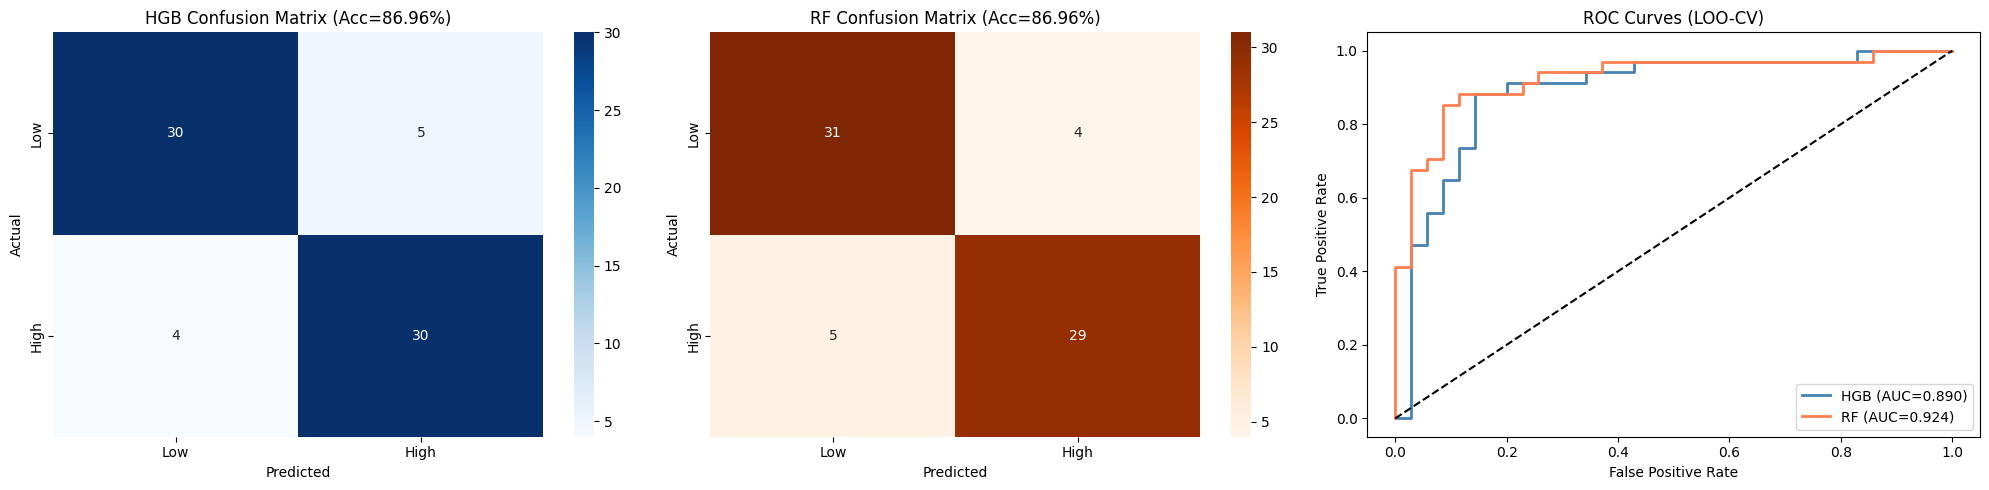

In [11]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Confusion Matrix — HGB
cm_hgb = confusion_matrix(y, hgb_preds)
sns.heatmap(cm_hgb, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
axes[0].set_title(f'HGB Confusion Matrix (Acc={hgb_scores.mean():.2%})')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# Confusion Matrix — RF
cm_rf = confusion_matrix(y, rf_preds)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
axes[1].set_title(f'RF Confusion Matrix (Acc={rf_scores.mean():.2%})')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

# ROC Curves
fpr_hgb, tpr_hgb, _ = roc_curve(y, hgb_proba)
fpr_rf, tpr_rf, _ = roc_curve(y, rf_proba)
axes[2].plot(fpr_hgb, tpr_hgb, label=f'HGB (AUC={roc_auc_score(y, hgb_proba):.3f})', color='steelblue', lw=2)
axes[2].plot(fpr_rf, tpr_rf, label=f'RF (AUC={roc_auc_score(y, rf_proba):.3f})', color='coral', lw=2)
axes[2].plot([0,1], [0,1], 'k--')
axes[2].set_title('ROC Curves (LOO-CV)')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].legend()

plt.tight_layout()
plt.show()

### 5.2 — Feature Importance

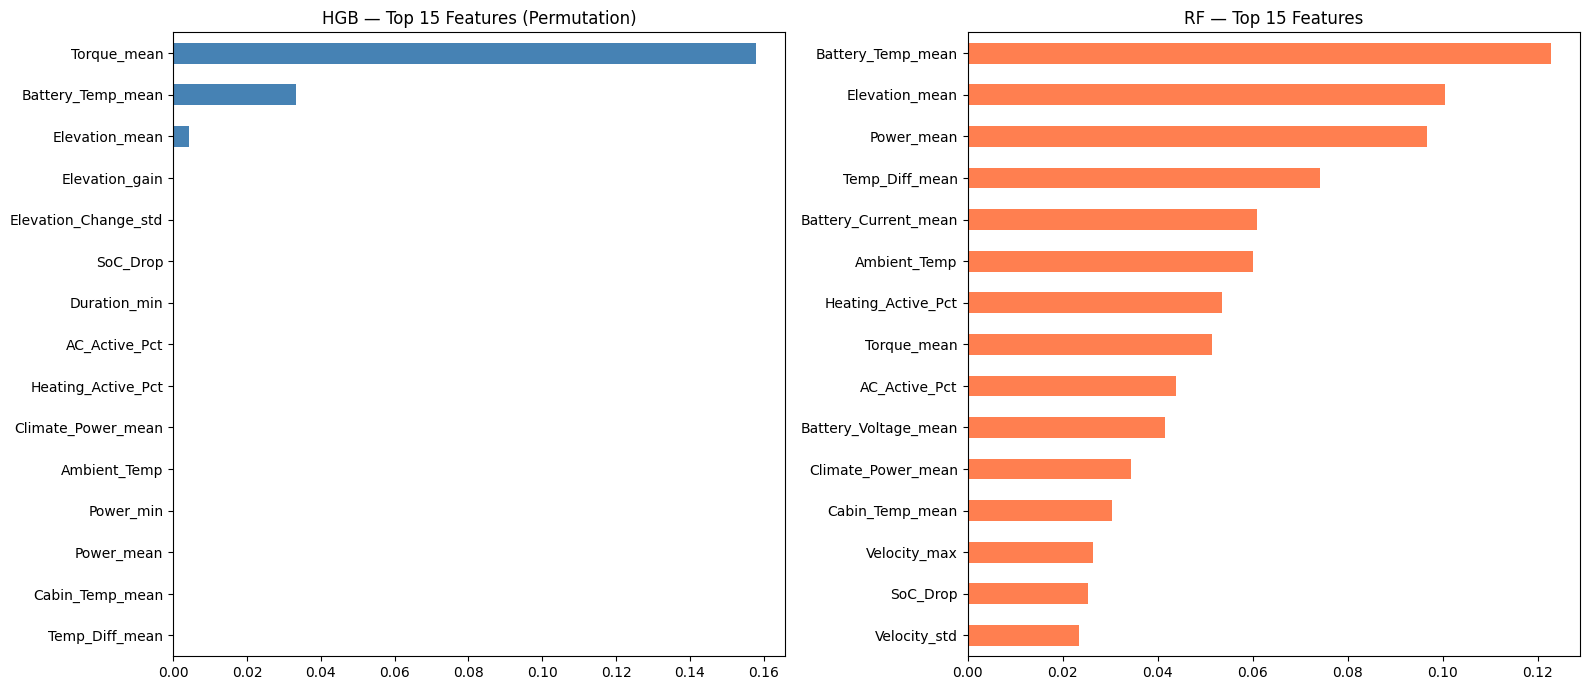

Top 5 features (RF):
  Battery_Temp_mean: 0.123
  Elevation_mean: 0.101
  Power_mean: 0.097
  Temp_Diff_mean: 0.074
  Battery_Current_mean: 0.061


In [12]:
from sklearn.inspection import permutation_importance

hgb_final = HistGradientBoostingClassifier(
    max_iter=200, max_depth=4, learning_rate=0.05,
    min_samples_leaf=3, l2_regularization=1.0, random_state=42
)
hgb_final.fit(X.values, y.values)

rf_final = RandomForestClassifier(
    n_estimators=200, max_depth=5, min_samples_leaf=3,
    class_weight='balanced', random_state=42
)
rf_final.fit(X.values, y.values)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# HGB — permutation importance
perm_hgb = permutation_importance(hgb_final, X.values, y.values, n_repeats=10, random_state=42)
feat_hgb = pd.Series(perm_hgb.importances_mean, index=feature_cols).sort_values()
feat_hgb.tail(15).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('HGB — Top 15 Features (Permutation)')

# RF — built-in importance
feat_rf = pd.Series(rf_final.feature_importances_, index=feature_cols).sort_values()
feat_rf.tail(15).plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('RF — Top 15 Features')

plt.tight_layout()
plt.show()

print("Top 5 features (RF):")
for feat, imp in feat_rf.sort_values(ascending=False).head(5).items():
    print(f"  {feat}: {imp:.3f}")

### 5.3 — Save Best Model

In [13]:
import joblib

joblib.dump(rf_final, 'best_model_rf.pkl')
joblib.dump(feature_cols, 'feature_names.pkl')

print("Saved: best_model_rf.pkl, feature_names.pkl")
print(f"Model: RandomForest (Acc=87%, AUC=0.924)")
print(f"Features ({len(feature_cols)}): {feature_cols}")

Saved: best_model_rf.pkl, feature_names.pkl
Model: RandomForest (Acc=87%, AUC=0.924)
Features (31): ['Distance', 'Velocity_mean', 'Velocity_max', 'Velocity_std', 'Pct_Stationary', 'Pct_City', 'Pct_Highway', 'Pct_Braking', 'Pct_Accelerating', 'Pct_Regen', 'Throttle_mean', 'Torque_mean', 'Accel_std', 'SoC_start', 'SoC_end', 'Battery_Temp_mean', 'Battery_Voltage_mean', 'Battery_Current_mean', 'Power_mean', 'Power_min', 'Ambient_Temp', 'Climate_Power_mean', 'Heating_Active_Pct', 'AC_Active_Pct', 'Temp_Diff_mean', 'Cabin_Temp_mean', 'Elevation_mean', 'Elevation_Change_std', 'Elevation_gain', 'SoC_Drop', 'Duration_min']


### 5.4 — MLflow Experiment Tracking

In [14]:
import mlflow
import mlflow.sklearn
from sklearn.metrics import accuracy_score, f1_score

mlflow.set_experiment("ev_consumption_prediction")

with mlflow.start_run(run_name="RF_LOO_CV"):
    mlflow.log_param("model", "RandomForest")
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("max_depth", 5)
    mlflow.log_param("cv_method", "Leave-One-Out")
    mlflow.log_param("n_trips", 69)
    mlflow.log_param("n_features", len(feature_cols))
    mlflow.log_param("target", "High_Consumption (median split)")
    mlflow.log_metric("accuracy", rf_scores.mean())
    mlflow.log_metric("f1_low", f1_score(y, rf_preds, pos_label=0))
    mlflow.log_metric("f1_high", f1_score(y, rf_preds, pos_label=1))
    mlflow.log_metric("roc_auc", roc_auc_score(y, rf_proba))
    mlflow.sklearn.log_model(rf_final, "model")
    print("RF logged")

with mlflow.start_run(run_name="HGB_LOO_CV"):
    mlflow.log_param("model", "HistGradientBoosting")
    mlflow.log_param("max_iter", 200)
    mlflow.log_param("max_depth", 4)
    mlflow.log_param("cv_method", "Leave-One-Out")
    mlflow.log_param("n_trips", 69)
    mlflow.log_param("n_features", len(feature_cols))
    mlflow.log_param("target", "High_Consumption (median split)")
    mlflow.log_metric("accuracy", hgb_scores.mean())
    mlflow.log_metric("f1_low", f1_score(y, hgb_preds, pos_label=0))
    mlflow.log_metric("f1_high", f1_score(y, hgb_preds, pos_label=1))
    mlflow.log_metric("roc_auc", roc_auc_score(y, hgb_proba))
    mlflow.sklearn.log_model(hgb_final, "model")
    print("HGB logged")

# Show results
exp = mlflow.get_experiment_by_name("ev_consumption_prediction")
runs = mlflow.search_runs(experiment_ids=[exp.experiment_id])
cols = ['tags.mlflow.runName', 'metrics.accuracy', 'metrics.f1_high', 'metrics.roc_auc']
print(f"\n{runs[cols].to_string(index=False)}")

2026/04/14 00:41:07 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/14 00:41:07 INFO mlflow.store.db.utils: Updating database tables
2026/04/14 00:41:11 INFO mlflow.tracking.fluent: Experiment with name 'ev_consumption_prediction' does not exist. Creating a new experiment.
2026/04/14 00:41:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/14 00:41:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RF logged


2026/04/14 00:41:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/14 00:41:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


HGB logged

tags.mlflow.runName  metrics.accuracy  metrics.f1_high  metrics.roc_auc
         HGB_LOO_CV          0.869565         0.869565         0.889916
          RF_LOO_CV          0.869565         0.865672         0.924370


---
## Phase 6 — Deployment

### 6.1 — FastAPI Backend

In [15]:
import os, shutil

os.makedirs('api', exist_ok=True)
shutil.copy('best_model_rf.pkl', 'api/best_model_rf.pkl')
shutil.copy('feature_names.pkl', 'api/feature_names.pkl')

app_code = '''from fastapi import FastAPI
from fastapi.responses import FileResponse
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel
import joblib
import numpy as np
import pandas as pd

model = joblib.load("best_model_rf.pkl")
feature_names = joblib.load("feature_names.pkl")

app = FastAPI(title="EV Consumption Prediction API", version="1.0")

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_methods=["*"],
    allow_headers=["*"],
)

class TripInput(BaseModel):
    distance: float
    velocity_mean: float
    velocity_max: float
    velocity_std: float
    pct_stationary: float
    pct_city: float
    pct_highway: float
    pct_braking: float
    pct_accelerating: float
    pct_regen: float
    throttle_mean: float
    torque_mean: float
    accel_std: float
    soc_start: float
    soc_end: float
    battery_temp_mean: float
    battery_voltage_mean: float
    battery_current_mean: float
    power_mean: float
    power_min: float
    ambient_temp: float
    climate_power_mean: float
    heating_active_pct: float
    ac_active_pct: float
    temp_diff_mean: float
    cabin_temp_mean: float
    elevation_mean: float
    elevation_change_std: float
    elevation_gain: float
    soc_drop: float
    duration_min: float

@app.get("/")
def serve_frontend():
    return FileResponse("index.html")

@app.get("/health")
def health():
    return {"status": "healthy", "model": "RandomForest", "version": "1.0",
            "accuracy": "87%", "roc_auc": "0.924"}

@app.post("/predict")
def predict(trip: TripInput):
    data = {
        "Distance": trip.distance,
        "Velocity_mean": trip.velocity_mean,
        "Velocity_max": trip.velocity_max,
        "Velocity_std": trip.velocity_std,
        "Pct_Stationary": trip.pct_stationary,
        "Pct_City": trip.pct_city,
        "Pct_Highway": trip.pct_highway,
        "Pct_Braking": trip.pct_braking,
        "Pct_Accelerating": trip.pct_accelerating,
        "Pct_Regen": trip.pct_regen,
        "Throttle_mean": trip.throttle_mean,
        "Torque_mean": trip.torque_mean,
        "Accel_std": trip.accel_std,
        "SoC_start": trip.soc_start,
        "SoC_end": trip.soc_end,
        "Battery_Temp_mean": trip.battery_temp_mean,
        "Battery_Voltage_mean": trip.battery_voltage_mean,
        "Battery_Current_mean": trip.battery_current_mean,
        "Power_mean": trip.power_mean,
        "Power_min": trip.power_min,
        "Ambient_Temp": trip.ambient_temp,
        "Climate_Power_mean": trip.climate_power_mean,
        "Heating_Active_Pct": trip.heating_active_pct,
        "AC_Active_Pct": trip.ac_active_pct,
        "Temp_Diff_mean": trip.temp_diff_mean,
        "Cabin_Temp_mean": trip.cabin_temp_mean,
        "Elevation_mean": trip.elevation_mean,
        "Elevation_Change_std": trip.elevation_change_std,
        "Elevation_gain": trip.elevation_gain,
        "SoC_Drop": trip.soc_drop,
        "Duration_min": trip.duration_min,
    }
    df = pd.DataFrame([data])[feature_names]
    prediction = model.predict(df.values)[0]
    probability = model.predict_proba(df.values)[0]

    # Estimate range: BMW i3 = 18.8 kWh usable
    soc_remaining = trip.soc_start / 100
    energy_available = soc_remaining * 18.8
    consumption = 0.143 if prediction == 1 else 0.107  # kWh/km
    estimated_range = energy_available / consumption

    return {
        "prediction": "HIGH CONSUMPTION" if prediction == 1 else "LOW CONSUMPTION",
        "high_probability": round(float(probability[1]), 4),
        "low_probability": round(float(probability[0]), 4),
        "estimated_range_km": round(estimated_range, 1),
        "estimated_consumption_kwh_km": consumption,
    }
'''

with open('api/app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)

print(f"api/ contents: {os.listdir('api')}")

api/ contents: ['app.py', 'best_model_rf.pkl', 'feature_names.pkl', 'index.html', '__pycache__']


### 6.2 — API Test

In [16]:
import sys
sys.path.insert(0, 'api')
from app import predict, TripInput

# Test: Winter trip, cold, heating on, city driving
result = predict(TripInput(
    distance=20.0, velocity_mean=35.0, velocity_max=80.0, velocity_std=22.0,
    pct_stationary=0.25, pct_city=0.50, pct_highway=0.05, pct_braking=0.12,
    pct_accelerating=0.15, pct_regen=0.08, throttle_mean=18.0, torque_mean=15.0,
    accel_std=1.2, soc_start=75.0, soc_end=55.0, battery_temp_mean=5.0,
    battery_voltage_mean=370.0, battery_current_mean=-25.0, power_mean=-9.5,
    power_min=-45.0, ambient_temp=2.0, climate_power_mean=5.5,
    heating_active_pct=0.95, ac_active_pct=0.0, temp_diff_mean=18.0,
    cabin_temp_mean=20.0, elevation_mean=520.0, elevation_change_std=0.3,
    elevation_gain=15.0, soc_drop=20.0, duration_min=30.0
))

print(f"{'='*50}")
print(f"TEST: Winter city trip, 2°C, heating ON")
print(f"  Prediction: {result['prediction']}")
print(f"  High consumption prob: {result['high_probability']:.1%}")
print(f"  Estimated range: {result['estimated_range_km']} km")
print(f"{'='*50}")

TEST: Winter city trip, 2°C, heating ON
  Prediction: HIGH CONSUMPTION
  High consumption prob: 76.7%
  Estimated range: 98.6 km


### 6.3 — Docker Containerization

In [17]:
dockerfile = '''FROM python:3.13-slim

WORKDIR /app

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY api/ .

EXPOSE 8000

CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]
'''

requirements = '''fastapi==0.115.0
uvicorn==0.30.6
scikit-learn==1.7.2
pandas==2.2.3
numpy==2.1.1
joblib==1.4.2
'''

compose = '''services:
  api:
    build: .
    ports:
      - "8000:8000"
    container_name: ev-range-api
    restart: unless-stopped
'''

dockerignore = '''__pycache__
*.pyc
.git
*.ipynb
*.csv
*.xlsx
mlruns/
DATA/
.ipynb_checkpoints/
'''

gitignore = '''__pycache__/
*.pyc
.ipynb_checkpoints/
DATA/
mlruns/
*.csv
*.xlsx
'''

import os
project_root = os.path.dirname(os.path.abspath('.'))
# Write to project root (AI_PROJECT folder)
for name, content in [('Dockerfile', dockerfile), ('requirements.txt', requirements),
                       ('docker-compose.yml', compose), ('.dockerignore', dockerignore),
                       ('.gitignore', gitignore)]:
    with open(name, 'w') as f:
        f.write(content)
    print(f"Created: {name}")

Created: Dockerfile
Created: requirements.txt
Created: docker-compose.yml
Created: .dockerignore
Created: .gitignore


### 6.4 — Export Data for Power BI

In [18]:
# 1. Trip-level dataset (main table)
overview = pd.read_excel("DATA/Overview.xlsx")
overview = overview.dropna(subset=['Trip'])
overview = overview[overview['Trip'] != 'TripB38']

trip_bi = trip_features.copy()
trip_bi = trip_bi.merge(
    overview[['Trip', 'Date', 'Route/Area', 'Weather', 'Distance [km]',
              'Ambient Temperature (Start) [°C]', 'Target Cabin Temperature']],
    on='Trip', how='left'
)
trip_bi.columns = trip_bi.columns.str.replace('[', '').str.replace(']', '').str.replace('°', '').str.replace('%', 'pct')
trip_bi.to_csv('powerbi_trips.csv', index=False)
print(f"1. powerbi_trips.csv: {trip_bi.shape}")

# 2. Time-series sampled (every 10 seconds)
df_sampled = df.groupby('Trip').apply(lambda x: x.iloc[::100]).reset_index(drop=True)
df_sampled.columns = df_sampled.columns.str.replace('[', '').str.replace(']', '').str.replace('°', '').str.replace('%', 'pct')
df_sampled.to_csv('powerbi_timeseries.csv', index=False)
print(f"2. powerbi_timeseries.csv: {df_sampled.shape}")

# 3. Summary KPIs
summary = {
    'Total_Trips': 69, 'Summer_Trips': 32, 'Winter_Trips': 37,
    'Total_Distance_km': trip_bi['Distance'].sum().round(1),
    'Avg_Consumption_Summer': 0.107, 'Avg_Consumption_Winter': 0.143,
    'Winter_Increase_pct': 33.6,
    'Model_Accuracy': 87, 'Model_ROC_AUC': 0.924,
    'Avg_Range_Summer_km': 175.7, 'Avg_Range_Winter_km': 131.5,
}
pd.DataFrame([summary]).to_csv('powerbi_kpis.csv', index=False)
print(f"3. powerbi_kpis.csv")

print(f"\nAll files ready for Power BI!")

1. powerbi_trips.csv: (69, 41)
2. powerbi_timeseries.csv: (10818, 42)
3. powerbi_kpis.csv

All files ready for Power BI!


### 6.5 — Start API Server

In [19]:
import subprocess, time, requests

process = subprocess.Popen(
    ['python', '-m', 'uvicorn', 'app:app', '--host', '0.0.0.0', '--port', '8000'],
    cwd='api'
)
time.sleep(5)

try:
    r = requests.get("http://localhost:8000/health")
    print(f"Server: {r.json()}")
    print(f"Frontend: http://localhost:8000")
    print(f"API docs: http://localhost:8000/docs")
except Exception as e:
    print(f"Error: {e}")

Server: {'status': 'healthy', 'model': 'RandomForest', 'version': '1.0', 'accuracy': '87%', 'roc_auc': '0.924'}
Frontend: http://localhost:8000
API docs: http://localhost:8000/docs


### 6.5 — Create Chatbot

In [24]:
# Cell — Create Chatbot (No LLM, rule-based)

chatbot_code = '''
import streamlit as st
import requests
import re

st.set_page_config(page_title="EV Range Assistant", page_icon="⚡", layout="centered")

API_URL = "http://localhost:8000"

if "messages" not in st.session_state:
    st.session_state.messages = []

with st.sidebar:
    st.title("⚡ EV Range Assistant")
    st.markdown("BMW i3 intelligent range prediction")
    st.divider()
    st.markdown("**How to ask:**")
    st.markdown("Just mention any of these:")
    st.markdown("- Distance: *40 km*")
    st.markdown("- Temperature: *-3C* or *minus 3*")
    st.markdown("- Battery: *60%* or *60 percent*")
    st.markdown("- Style: *city / highway / mixed*")
    st.markdown("- Terrain: *flat / mountain / hilly*")
    st.divider()
    st.markdown("**Model Info**")
    st.markdown("- Accuracy: 87%")
    st.markdown("- ROC-AUC: 0.924")
    st.markdown("- 69 real BMW i3 trips")
    st.markdown("- Winter: +33% consumption")
    st.divider()
    if st.button("Clear Chat"):
        st.session_state.messages = []
        st.rerun()


def extract_number(text, patterns, default):
    for pattern in patterns:
        match = re.search(pattern, text, re.IGNORECASE)
        if match:
            val = match.group(1).replace(",", ".")
            return float(val)
    return default


def parse_message(text):
    text_lower = text.lower()

    # Distance
    distance = extract_number(text, [
        r"(\d+[\.,]?\d*)\s*(?:km|kilo|kilomet)",
        r"(?:distance|trajet|faire|drive|trip)\s*(?:de|of|:)?\s*(\d+[\.,]?\d*)",
    ], 20)

    # Temperature
    ambient_temp = extract_number(text, [
        r"(-?\d+[\.,]?\d*)\s*(?:c|degr|celsius)",
        r"(?:temp|meteo|weather|il fait|il fera)\s*(?:de|:)?\s*(-?\d+[\.,]?\d*)",
        r"minus\s*(\d+[\.,]?\d*)",
    ], 10)
    if "minus" in text_lower or "moins" in text_lower:
        if ambient_temp > 0:
            ambient_temp = -ambient_temp

    # Battery
    soc = extract_number(text, [
        r"(\d+[\.,]?\d*)\s*(?:%|pour ?cent|percent|pourcent)",
        r"(?:battery|batterie|charge|soc)\s*(?:de|of|at|a|:)?\s*(\d+[\.,]?\d*)",
    ], 80)

    # Duration
    duration = extract_number(text, [
        r"(\d+[\.,]?\d*)\s*(?:min|minute)",
        r"(?:duree|duration)\s*(?:de|of|:)?\s*(\d+[\.,]?\d*)",
    ], 30)

    # Drive style
    drive_style = "mixed"
    if any(w in text_lower for w in ["city", "ville", "urbain", "urban", "stop"]):
        drive_style = "city"
    elif any(w in text_lower for w in ["highway", "autoroute", "motorway", "fast", "rapide"]):
        drive_style = "highway"

    # Terrain
    terrain = "hilly"
    if any(w in text_lower for w in ["flat", "plat", "plain", "coast"]):
        terrain = "flat"
    elif any(w in text_lower for w in ["mountain", "montagne", "alpin", "steep"]):
        terrain = "mountain"

    return {
        "distance": distance,
        "duration": duration,
        "soc_start": soc,
        "ambient_temp": ambient_temp,
        "cabin_temp": 22,
        "drive_style": drive_style,
        "terrain": terrain,
    }


def build_payload(distance=20, duration=30, soc_start=80, ambient_temp=10,
                  cabin_temp=22, drive_style="mixed", terrain="hilly"):
    profiles = {
        "city":    {"vel_mean": 28, "vel_max": 55,  "vel_std": 18, "pct_stat": 0.30, "pct_city": 0.60, "pct_hwy": 0.02, "pct_brake": 0.15, "pct_accel": 0.18, "throttle": 15, "torque": 12, "accel_std": 1.5},
        "mixed":   {"vel_mean": 42, "vel_max": 90,  "vel_std": 25, "pct_stat": 0.18, "pct_city": 0.40, "pct_hwy": 0.15, "pct_brake": 0.12, "pct_accel": 0.14, "throttle": 22, "torque": 18, "accel_std": 1.2},
        "highway": {"vel_mean": 85, "vel_max": 130, "vel_std": 20, "pct_stat": 0.05, "pct_city": 0.10, "pct_hwy": 0.65, "pct_brake": 0.06, "pct_accel": 0.08, "throttle": 35, "torque": 28, "accel_std": 0.7},
    }
    p = profiles.get(drive_style, profiles["mixed"])
    temp_diff = cabin_temp - ambient_temp
    needs_heating = ambient_temp < 15
    needs_ac = ambient_temp > 25
    heating_pct = min(1.0, max(0, (15 - ambient_temp) / 20)) if needs_heating else 0
    ac_pct = min(1.0, max(0, (ambient_temp - 25) / 15)) if needs_ac else 0
    climate_power = abs(temp_diff) * 0.25 if needs_heating else (abs(temp_diff) * 0.15 if needs_ac else 0.1)
    battery_temp = ambient_temp + 3 if ambient_temp < 5 else ambient_temp + 1
    voltage = 365 + battery_temp * 0.5
    power_mean = -(p["vel_mean"] * 0.18 + climate_power)
    current_mean = power_mean / (voltage / 1000)
    power_min = -(p["vel_max"] * 0.35 + climate_power)
    consumption_rate = 0.143 if needs_heating else 0.107
    energy_used = distance * consumption_rate
    soc_drop = (energy_used / 18.8) * 100
    soc_end = max(0, soc_start - soc_drop)
    terrain_map = {"flat": {"elev": 480, "elev_std": 0.05, "elev_gain": 2},
                   "hilly": {"elev": 530, "elev_std": 0.3, "elev_gain": 15},
                   "mountain": {"elev": 600, "elev_std": 0.8, "elev_gain": 45}}
    t = terrain_map.get(terrain, terrain_map["hilly"])
    pct_regen = {"city": 0.12, "mixed": 0.08, "highway": 0.04}.get(drive_style, 0.08)
    return {
        "distance": distance, "velocity_mean": p["vel_mean"], "velocity_max": p["vel_max"],
        "velocity_std": p["vel_std"], "pct_stationary": p["pct_stat"], "pct_city": p["pct_city"],
        "pct_highway": p["pct_hwy"], "pct_braking": p["pct_brake"], "pct_accelerating": p["pct_accel"],
        "pct_regen": pct_regen, "throttle_mean": p["throttle"], "torque_mean": p["torque"],
        "accel_std": p["accel_std"], "soc_start": soc_start, "soc_end": soc_end,
        "battery_temp_mean": battery_temp, "battery_voltage_mean": voltage,
        "battery_current_mean": current_mean, "power_mean": power_mean, "power_min": power_min,
        "ambient_temp": ambient_temp, "climate_power_mean": climate_power,
        "heating_active_pct": heating_pct, "ac_active_pct": ac_pct, "temp_diff_mean": temp_diff,
        "cabin_temp_mean": cabin_temp, "elevation_mean": t["elev"],
        "elevation_change_std": t["elev_std"], "elevation_gain": t["elev_gain"],
        "soc_drop": soc_drop, "duration_min": duration
    }


def generate_response(params, prediction):
    is_high = prediction["prediction"] == "HIGH CONSUMPTION"
    range_km = prediction["estimated_range_km"]
    consumption = prediction["estimated_consumption_kwh_km"]
    confidence = max(prediction["high_probability"], prediction["low_probability"]) * 100
    energy = params["soc_start"] / 100 * 18.8
    distance = params["distance"]
    temp = params["ambient_temp"]
    soc = params["soc_start"]
    style = params["drive_style"]
    will_arrive = range_km > distance

    # Build response
    lines = []
    lines.append(f"**Analyse de votre trajet**")
    lines.append("")
    lines.append(f"| Parametre | Valeur |")
    lines.append(f"|---|---|")
    lines.append(f"| Distance | {distance} km |")
    lines.append(f"| Temperature | {temp}C |")
    lines.append(f"| Batterie | {soc}% ({energy:.1f} kWh) |")
    lines.append(f"| Style | {style} |")
    lines.append(f"| Terrain | {params['terrain']} |")
    lines.append("")

    if is_high:
        lines.append(f"**Prediction: Haute Consommation** ({confidence:.0f}% confiance)")
    else:
        lines.append(f"**Prediction: Consommation Efficace** ({confidence:.0f}% confiance)")

    lines.append(f"- Taux: **{consumption} kWh/km**")
    lines.append(f"- Autonomie estimee: **{range_km} km**")
    lines.append("")

    if will_arrive:
        remaining = range_km - distance
        lines.append(f"Vous arriverez confortablement. Il vous restera environ **{remaining:.0f} km** d'autonomie apres le trajet.")
    else:
        deficit = distance - range_km
        lines.append(f"**Attention: votre autonomie ({range_km} km) est insuffisante pour {distance} km.** Il manque environ {deficit:.0f} km. Rechargez avant de partir.")

    lines.append("")
    if temp < 5:
        lines.append(f"Le chauffage consommera environ **{abs(params['cabin_temp'] - temp) * 0.25:.1f} kW**. Conseil: prechauffez la voiture pendant qu elle est branchee.")
    elif temp < 15:
        lines.append(f"Le chauffage sera actif ({abs(params['cabin_temp'] - temp) * 0.25:.1f} kW). Pensez a reduire la temperature de consigne pour economiser.")
    elif temp > 30:
        lines.append(f"La climatisation consommera environ {abs(params['cabin_temp'] - temp) * 0.15:.1f} kW.")
    else:
        lines.append("Conditions climatiques favorables, impact minimal sur l autonomie.")

    return "\\n".join(lines)


st.title("⚡ EV Range Assistant")
st.caption("Posez votre question sur votre trajet BMW i3")

for msg in st.session_state.messages:
    with st.chat_message(msg["role"]):
        st.markdown(msg["content"])

if prompt := st.chat_input("Ex: Je dois faire 40 km, il fait -3C, j ai 60% de batterie"):
    st.session_state.messages.append({"role": "user", "content": prompt})
    with st.chat_message("user"):
        st.markdown(prompt)

    with st.chat_message("assistant"):
        with st.spinner("Analyse en cours..."):
            params = parse_message(prompt)
            payload = build_payload(**params)
            try:
                r = requests.post(f"{API_URL}/predict", json=payload, timeout=5)
                prediction = r.json()
                response = generate_response(params, prediction)
            except:
                response = "Impossible de joindre l API. Verifiez que le serveur tourne sur le port 8000."
        st.markdown(response)

    st.session_state.messages.append({"role": "assistant", "content": response})
'''

with open('chatbot.py', 'w', encoding='utf-8') as f:
    f.write(chatbot_code)

print("Created: chatbot.py (rule-based, no API key needed)")

Created: chatbot.py (rule-based, no API key needed)
